In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np

In [2]:
df = pd.read_csv(os.path.join('dataset', 'trail_running.csv'), sep=';')
df.columns = ['Gara', 'Lunghezza', 'D+', 'Tempo']
df['Lunghezza'] = df['Lunghezza']*1000
df['Tempo'] = pd.to_timedelta(df['Tempo']).dt.total_seconds()/60
df.columns = ['Gara', 'Lunghezza', 'D+', 'Minuti']
df = df[df['Lunghezza'] < 100000]

# implementiamo regressione lineare con gradient descent
* **normalizzazione**: se ci sono molti ordini di grandezza di differenza in una feature, avro problemi con la regressione. voglio che tutte le feature abbiano la stessa *importanza*
* **come si normalizza**? voglio media pari a 0 e deviazione standard pari a 1. la formula e' $X_{std} = \frac{X - mean(X)}{stddev(X)}$ dove $X$ e' la lista di valori da normalizzare.
* **a che serve**? mi evita numeri enormi se ci sono (dunque convergenza lenta e overflow)

In [3]:
class LinearRegressionGD(object):
    def __init__(self, eta=0.001, n_iter=1000):
        self.eta = eta
        self.n_iter = n_iter

    def fit(self, X, y):
        # Standardizzazione delle feature, opero colonna per colonna con axis=0
        self.mean_ = X.mean(axis=0)
        self.std_ = X.std(axis=0)
        # applico la formula, si fa sempre a meno che il modello sia insensibile
        X_std = (X - self.mean_) /self.std_

        # inizializzazione pesi
        self.w_ = np.zeros(1+X.shape[1]) # devo aggiungere una colonna 

        # fai la discesa del gradiente 
        for _ in range(self.n_iter):
            output = self.net_input(X_std)
            errors = y - output

            # attenzione alla divisione sul numero dei campioni
            self.w_[1:] += self.eta * X_std.T.dot(errors)/X.shape[0]
            self.w_[0] += self.eta * errors.sum()/X.shape[0]
            # cosa cambia? teoricamente e' una costante quindi nulla
            # in pratica? ho numeri piu piccoli da gestire
    
    def net_input(self, X):
        return np.dot(X, self.w_[1:]) + self.w_[0]

    def predict(self, X):
        # standardizza X
        X_std = (X - self.mean_) / self.std_
        # e poi fai la previsione
        return self.net_input(X_std)

    def get_coef(self):
        """
        ritorna l'intercetta, ossia w0 ed i coefficienti
        """
        # devo ricalcolare i coefficienti originali
        coef = self.w_[1:] / self.std_
        
        intercept = self.w_[0] - np.sum(self.w_[1:] * self.mean_ / self.std_)

        return intercept, coef

# come ottengo l'intercetta dai dati standardizzati?
$$
x_i^{\texttt{std}} = \frac{x_i - \mu_i}{\sigma_i}
$$

Partendo da

$$
y = w_0^{\texttt{std}} + \sum_{i=1}^{d} w_i^{\texttt{std}} x_i^{\texttt{std}}
$$

allora

$$
y = w_0^{\texttt{std}} + \sum_{i=1}^{d} w_i^{\texttt{std}} \frac{x_i - \mu_i}{\sigma_i}
$$

da cui segue

$$
y = w_0^{\texttt{std}} - \sum_{i=1}^{d} \frac{w_i^{\texttt{std}} \mu_i}{\sigma_i}   +  \sum_{i=1}^{d} \frac{w_i^{\texttt{std}}}{\sigma_i} x_i.
$$

Quindi nello spazio delle feature originali abbiamo i seguenti valori per intercetta e coefficienti:

$$
w_0^{\texttt{std}} - \sum_{i=1}^{d} \frac{w_i^{\texttt{std}} \mu_i}{\sigma_i}, \quad
\left(\frac{w_1^{\texttt{std}}}{\sigma_1},\ldots,\frac{w_d^{\texttt{std}}}{\sigma_d} \right)
$$

### Valutazione dell'errore

Se $y_i$ sono i valori reali e $z_i$ quelli predetti, l'**errore medio assoluto** (MAE, *mean absolute error*) è dato da

$$
\frac{1}{n}\sum_{i=1}^{n} |y_i - z_i|
$$

In [4]:
def mae(y ,z):
    return np.sum(np.abs(y-z))/y.shape[0]

In [5]:
X = df[ ['Lunghezza'] ].values
y = df['Minuti'].values

linreg = LinearRegressionGD(eta=0.002, n_iter=5000)

linreg.fit(X, y)

previsioni = linreg.predict(X)

# Valori reali che il modello sta cercando di prevedere
valori_reali = y

# Calcolo del Mean Absolute Error
error = mae(valori_reali, previsioni)

print(f"Mean Absolute Error (MAE): {error:.2f}")

Mean Absolute Error (MAE): 22.02


[2.58179112]


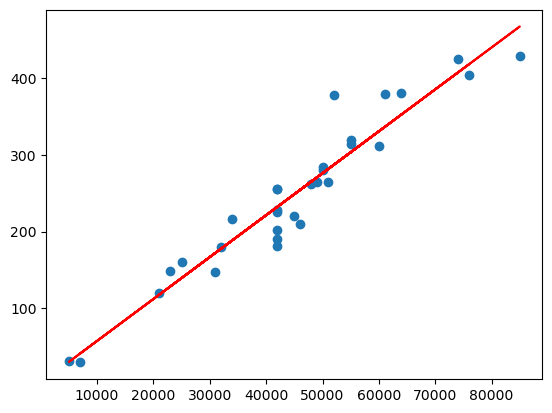

In [6]:
# disegna i dati come punti
plt.scatter(X,y)
# disegna i dati come una linea
plt.plot(X, previsioni, c='r')
print(linreg.predict(np.array([[0]])))

# combinare piu feature!
**oss**: vediamo che minchia succede! magari migliora l'errore

In [7]:
X = df[ ['Lunghezza', 'D+'] ].values 
y = df['Minuti']

linreg = LinearRegressionGD(eta = 0.01, n_iter=2500)

linreg.fit(X, y)

previsioni = linreg.predict(X)

# oppure usando i intercetta e coefficienti
intercept, coef = linreg.get_coef()
previsioni = intercept + np.dot(X, coef)

# Valori reali che il modello sta cercando di prevedere
valori_reali = y

# Calcolo del Mean Absolute Error
error = mae(valori_reali, previsioni)

print(f"Mean Absolute Error (MAE): {error:.2f}")

Mean Absolute Error (MAE): 14.09


### esercizio 1: costo del `fit`
* **calcolare la media**: $\Theta(nd)$
* **calcolare la deviazione standard**: $\Theta(nd)$
* **inizializzazione pesi**: $\Theta(d)$
* **numero iterazioni for**: $\text{n\_iter}$
* `self.net_input`: devo fare $d$ prodotti scalari da sommare, per tutti i campioni, dunque $\Theta(nd)$
* `errors = y - output` $\Theta(n)$
* `self.eta * X_std.T.dot(errors)/X.shape[0]`: $nd$ per fare la trasposta, poi il prodotto con error costa $\Theta(nd^2)$ ???
* `self.w_[0] += self.eta * errors.sum()/X.shape[0]` $\Theta(n)$


### esercizio 2
**consegna**: implementare `LinearRegressionGD` in modo che il criterio di terminazione dell'addestramento sia soddisfatto quando $J(w)$ smette di diminuire in modo significativo